# Modeling Human Activity States Using Hidden Markov Models

**Formative 2 — Hidden Markov Models**

This notebook infers hidden human-activity states (**still, standing, walking, jumping**) from
smartphone **accelerometer** and **gyroscope** signals using a Hidden Markov Model (HMM).

**Pipeline:** raw sensor CSVs → uniform resampling → sliding-window segmentation →
time- & frequency-domain feature extraction → Z-score normalization → HMM
(**Baum–Welch** training, **Viterbi** decoding) → evaluation on **2 unseen test files**.

**Use case (motivation):** wearable activity recognition underpins fitness trackers,
fall detection for the elderly, and clinical gait monitoring. In all of these the *true*
activity is hidden and must be inferred from noisy inertial signals — exactly the latent-state
setting an HMM is built for.

## 0. Setup

In [1]:
import sys, os
# --- local-libraries bridge: this repo ships its Python deps in ./.pylibs ---
# (Inside a normal virtualenv with the packages installed this is a harmless no-op.)
_libs = os.path.abspath('.pylibs')
if os.path.isdir(_libs) and _libs not in sys.path:
    sys.path.insert(0, _libs)

import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.fft import rfft, rfftfreq
from hmmlearn import hmm
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import confusion_matrix, accuracy_score

np.random.seed(42)
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 110
os.makedirs('figures', exist_ok=True)
print('Environment ready.')

Environment ready.


In [2]:
# ---- Configuration ----
DATA = 'Datasets'
FS         = 100.0        # target uniform sampling rate (Hz)
WIN_SEC    = 2.0         # window length in seconds
OVERLAP    = 0.5        # 50% window overlap
WIN        = int(WIN_SEC * FS)          # samples per window = 200
STEP       = int(WIN * (1 - OVERLAP))   # hop = 100 samples
TRAIN_FRAC = 0.60        # train on the first 60% of each recording (by time)

ACTS = ['still', 'standing', 'walking', 'jumping']
IDX  = {a: i for i, a in enumerate(ACTS)}

# activity -> (accelerometer file, gyroscope file)
FILES = {
    'still':    ('Nziza flat .csv',    'Flat Gyroscope.csv'),
    'standing': ('Nziza standing.csv', 'Standing Gyroscope.csv'),
    'walking':  ('Nziza walking.csv',  'Walking Gyroscope.csv'),
    'jumping':  ('Nziza jumping.csv',  'Jumping Gyeoscope.csv'),
}
# 2 held-out UNSEEN test files (built from the last 40% of each recording)
TEST_FILES = ['Datasets/unseen_test/test_session_1.csv',
              'Datasets/unseen_test/test_session_2.csv']

## 1. Data Collection & Sampling Rate

Data were recorded with the **Physics Toolbox** app on a single smartphone. Each of the four
activities was captured as a continuous recording; the accelerometer (`ax,ay,az`) and gyroscope
(`wx,wy,wz`) streams were logged separately, each with its own `time` column (seconds).

The cell below measures the **actual sampling rate** of every file from the median time step.

In [3]:
raw_files = sorted({fn for pair in FILES.values() for fn in pair})
rows = []
for fn in raw_files:
    d = pd.read_csv(f'{DATA}/{fn}'); t = d['time'].values.astype(float)
    rows.append({'file': fn, 'rows': len(d),
                 'duration_s': round(t[-1]-t[0], 2),
                 'fs_Hz': round(1/np.median(np.diff(t)), 1),
                 'sensor': 'accel' if 'ax (m/s^2)' in d.columns else 'gyro'})
rate_tbl = pd.DataFrame(rows)
display(rate_tbl)
print(f"Mean sampling rate: {rate_tbl.fs_Hz.mean():.1f} Hz  "
      f"(min {rate_tbl.fs_Hz.min()}, max {rate_tbl.fs_Hz.max()})")

,file,rows,duration_s,fs_Hz,sensor
0,Flat Gyroscope.csv,1760,18.04,97.6,gyro
1,Jumping Gyeoscope.csv,1299,13.31,97.6,gyro
2,Nziza flat .csv,3542,35.95,98.8,accel
3,Nziza jumping.csv,1096,11.09,98.8,accel
4,Nziza standing.csv,1054,10.66,98.9,accel
5,Nziza walking.csv,2262,22.90,98.6,accel
6,Standing Gyroscope.csv,1285,13.15,97.7,gyro
7,Walking Gyroscope.csv,1347,13.80,97.5,gyro


Mean sampling rate: 98.2 Hz  (min 97.5, max 98.9)


**Sampling-rate harmonization.** All files sit at ~98 Hz (a single device was used), so the
rates are already close. Timestamps are nevertheless *slightly irregular*, so we resample every
stream onto a **uniform 100 Hz grid** by linear interpolation. This (a) gives an exact,
constant sample spacing that the FFT features assume, and (b) is the mechanism by which recordings
from *different* devices/rates would be harmonized if more phones were used.

In [4]:
def load_uniform(path, cols):
    """Load a sensor CSV and resample onto a uniform FS grid via linear interpolation."""
    df = pd.read_csv(path)
    t = df['time'].values.astype(float); t = t - t[0]
    tg = np.arange(int(t[-1] * FS)) / FS            # uniform time grid
    return np.column_stack([np.interp(tg, t, df[c].values.astype(float)) for c in cols])

ACC_COLS = ['ax (m/s^2)', 'ay (m/s^2)', 'az (m/s^2)']
GYR_COLS = ['wx (rad/s)', 'wy (rad/s)', 'wz (rad/s)']

def paired_stream(activity, lo=0.0, hi=1.0):
    """Resample accel & gyro for an activity, keep the [lo,hi) time-fraction, pair by index."""
    af, gf = FILES[activity]
    a = load_uniform(f'{DATA}/{af}', ACC_COLS)
    g = load_uniform(f'{DATA}/{gf}', GYR_COLS)
    a = a[int(len(a)*lo):int(len(a)*hi)]
    g = g[int(len(g)*lo):int(len(g)*hi)]
    n = min(len(a), len(g))
    return pd.DataFrame(np.column_stack([a[:n], g[:n]]),
                        columns=['ax','ay','az','wx','wy','wz'])

streams_full = {a: paired_stream(a) for a in ACTS}   # full streams, for plotting
print('Resampled all four activities to a uniform', FS, 'Hz grid.')

Resampled all four activities to a uniform 100.0 Hz grid.


### 1.1 Sample raw signals
A quick look at the accelerometer and gyroscope magnitude for each activity.

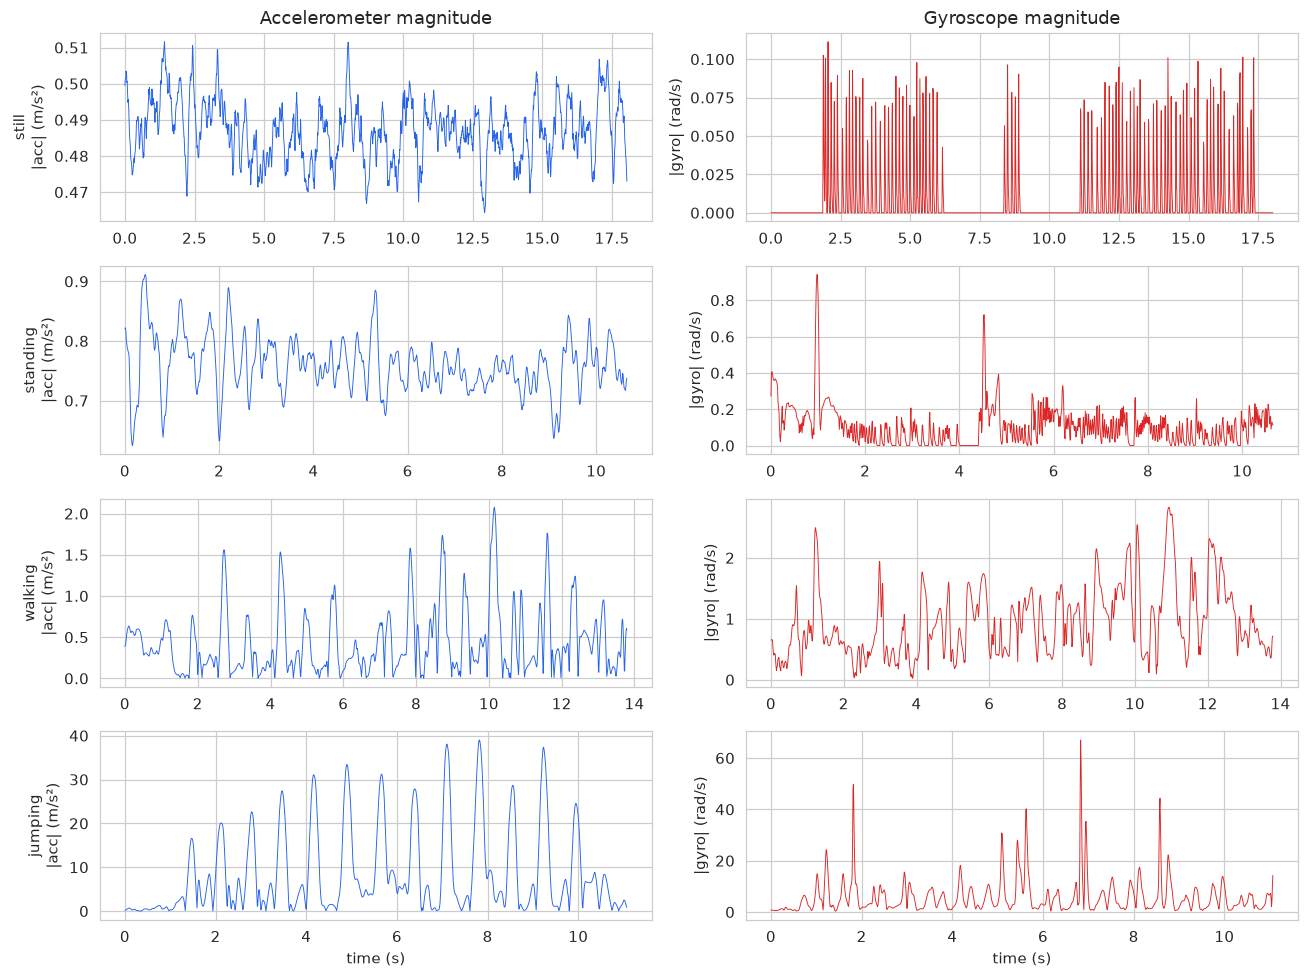

In [5]:
fig, ax = plt.subplots(4, 2, figsize=(12, 9))
for r, a in enumerate(ACTS):
    s = streams_full[a]; t = np.arange(len(s)) / FS
    ax[r, 0].plot(t, np.linalg.norm(s[['ax','ay','az']].values, axis=1), lw=.6, color='#2563eb')
    ax[r, 0].set_ylabel(f'{a}\n|acc| (m/s²)')
    ax[r, 1].plot(t, np.linalg.norm(s[['wx','wy','wz']].values, axis=1), lw=.6, color='#dc2626')
    ax[r, 1].set_ylabel('|gyro| (rad/s)')
ax[0, 0].set_title('Accelerometer magnitude'); ax[0, 1].set_title('Gyroscope magnitude')
ax[3, 0].set_xlabel('time (s)'); ax[3, 1].set_xlabel('time (s)')
plt.tight_layout(); plt.savefig('figures/raw_signals.png', bbox_inches='tight'); plt.show()

## 2. Windowing & Feature Extraction

**Window size.** At `FS = 100 Hz` we use **2-second windows (200 samples) with 50% overlap**.
Human locomotion is periodic at roughly 1–3 Hz (walking ≈2 steps/s, jumping ≈1–2 jumps/s), so a
2 s window spans **2–6 full activity cycles** — long enough for stable frequency-domain estimates
yet short enough that the signal stays approximately stationary within the window. The 50% overlap
doubles the number of windows and smooths window-boundary effects. Window length in *samples* is
derived directly from the sampling rate (`WIN = WIN_SEC × FS`), which is how the windowing adapts
if the rate changes.

**Sensor fusion note.** Accelerometer and gyroscope were recorded in *separate* sessions per
activity (independent clocks), so they cannot be fused sample-by-sample. Because each recording is
a single, stationary activity, we window each stream and **pair samples by index**, giving one
combined feature vector per window.

**Features per window** (time- and frequency-domain):
- *Per axis* (ax, ay, az, wx, wy, wz): `mean, std, var, rms, min, max` (time) and
  `dominant frequency, spectral energy, spectral entropy` (frequency, from the FFT).
- *Cross-axis:* accelerometer pairwise correlations (axy, axz, ayz).
- *Aggregate:* Signal Magnitude Area (SMA) for accel and gyro.

In [6]:
def feats_axis(x):
    """Time + frequency features for a single 1-D window."""
    f = {'mean': np.mean(x), 'std': np.std(x), 'var': np.var(x),
         'rms': np.sqrt(np.mean(x**2)), 'min': np.min(x), 'max': np.max(x)}
    xd = x - np.mean(x)                       # remove DC before FFT
    sp = np.abs(rfft(xd))**2                  # power spectrum
    fr = rfftfreq(len(xd), 1/FS)
    f['energy'] = np.sum(sp) / len(xd)        # spectral energy
    if sp[1:].sum() > 0:
        f['dom_freq'] = fr[1 + np.argmax(sp[1:])]           # dominant frequency
        p = sp[1:] / sp[1:].sum()
        f['spec_ent'] = -np.sum(p * np.log(p + 1e-12))      # spectral entropy
    else:
        f['dom_freq'] = 0.0; f['spec_ent'] = 0.0
    return f

def window_features(win):
    """win: DataFrame slice with columns ax,ay,az,wx,wy,wz -> feature dict."""
    aw = win[['ax','ay','az']].values; gw = win[['wx','wy','wz']].values
    fv = {}
    for nm, c in zip(['ax','ay','az'], range(3)):
        fv.update({f'{nm}_{k}': v for k, v in feats_axis(aw[:, c]).items()})
    for nm, c in zip(['wx','wy','wz'], range(3)):
        fv.update({f'{nm}_{k}': v for k, v in feats_axis(gw[:, c]).items()})
    fv['acc_sma'] = np.mean(np.sum(np.abs(aw), axis=1))     # signal magnitude area
    fv['gyr_sma'] = np.mean(np.sum(np.abs(gw), axis=1))
    for (i, j), nm in zip([(0,1),(0,2),(1,2)], ['axy','axz','ayz']):
        c = np.corrcoef(aw[:, i], aw[:, j])[0, 1]
        fv[f'corr_{nm}'] = 0.0 if np.isnan(c) else c
    return fv

def windows_of(block):
    """Yield fixed windows over a same-activity DataFrame block."""
    for s in range(0, len(block) - WIN + 1, STEP):
        yield block.iloc[s:s + WIN]

### 2.1 Training features (first 60% of each recording)

The model is trained **only on the head 60%** of every recording; the last 40% is reserved,
untouched, for the unseen test files built in a separate step.

In [7]:
rows = []
for a in ACTS:
    head = paired_stream(a, 0.0, TRAIN_FRAC)          # head region only
    for win in windows_of(head):
        fv = window_features(win); fv['activity'] = a
        rows.append(fv)
train_df = pd.DataFrame(rows)
FEATS = [c for c in train_df.columns if c != 'activity']
print(f'{len(train_df)} training windows, {len(FEATS)} features each')
print(train_df['activity'].value_counts().to_string())
train_df.head()

26 training windows, 59 features each
activity
still       9
walking     7
standing    5
jumping     5


,ax_mean,ax_std,ax_var,ax_rms,ax_min,ax_max,ax_energy,ax_dom_freq,ax_spec_ent,ay_mean,...,wz_max,wz_energy,wz_dom_freq,wz_spec_ent,acc_sma,gyr_sma,corr_axy,corr_axz,corr_ayz,activity
0,0.036484,0.000657,4.321985e-07,0.036489,0.034863,0.038619,0.000043,1.5,2.323041,-0.042356,...,0.0,0.021945,0.5,3.430895,0.568279,0.003455,-0.425039,0.724021,-0.774650,still
1,0.036181,0.000720,5.188242e-07,0.036188,0.034100,0.037746,0.000052,2.0,2.014576,-0.042643,...,0.0,0.060649,0.5,3.388910,0.569184,0.015979,-0.684751,0.889601,-0.754984,still
2,0.036130,0.000717,5.136235e-07,0.036138,0.034100,0.037600,0.000051,2.5,2.349476,-0.042086,...,0.0,0.060714,9.0,3.216633,0.566127,0.021173,-0.652710,0.849764,-0.706511,still
3,0.035797,0.000859,7.380906e-07,0.035807,0.033700,0.037400,0.000074,0.5,1.819942,-0.041354,...,0.0,0.053698,7.0,3.247406,0.560771,0.018026,-0.582574,0.821006,-0.738394,still
4,0.035417,0.000701,4.917715e-07,0.035424,0.033700,0.036964,0.000049,0.5,2.155285,-0.040845,...,0.0,0.064085,8.0,2.833532,0.555807,0.021665,-0.367273,0.719669,-0.671200,still


## 3. HMM Model Components

| Element | In this project |
|---|---|
| **Hidden states Z** | the 4 activities: still, standing, walking, jumping |
| **Observations X** | 59-D feature vectors per window (→ PCA-reduced) |
| **Transition A** | P(activity at t+1 \| activity at t) |
| **Emission B** | Gaussian density of features given an activity |
| **Initial π** | probability the sequence starts in each activity |

We reduce the 59 correlated features with **PCA** (fit on the training set only) so the Gaussian
emissions stay well-conditioned given the modest number of windows.

### 3.1 Normalization (Z-score) + PCA
Scaler and PCA are fit on **training data only** to avoid leakage.

In [8]:
Xtr_raw = train_df[FEATS].values
ytr = train_df['activity'].map(IDX).values

scaler = StandardScaler().fit(Xtr_raw)
pca = PCA(n_components=6, random_state=42).fit(scaler.transform(Xtr_raw))
def transform(Xraw): return pca.transform(scaler.transform(Xraw))
Xtr = transform(Xtr_raw)
print(f'PCA kept {pca.n_components_} comps, '
      f'{pca.explained_variance_ratio_.sum():.1%} of variance')

PCA kept 6 comps, 93.7% of variance


## 4. HMM Implementation — Baum–Welch training

We initialise the emissions with **supervised estimates** (per-activity means/variances from the
labelled training windows) and then refine them with **Baum–Welch (EM, `GaussianHMM.fit`)**. Training
stops when the **change in log-likelihood falls below `tol` (1e-4)** — a proper convergence check
rather than a fixed iteration count.

**Why the transition matrix is a fixed prior, not learned.** The four activities were recorded in
*separate* single-activity sessions, so the training data contains **no natural inter-activity
transitions** to estimate `A` from. Estimating `A` from an arbitrary concatenation of those
recordings would encode a meaningless ordering. We therefore fix `A` to a **principled prior** —
strong self-persistence (0.90) with a small, unbiased uniform off-diagonal — encoding the domain fact
that *activities persist over consecutive windows and, when they do change, no particular switch is
favoured*. Baum–Welch learns the **discriminative part (the emissions)**; the initial distribution is
uniform since any activity may start a sequence. Each hidden state stays aligned with a known
activity, so the decoded states are directly interpretable.

In [9]:
NS = 4
# each activity recording is fed as its own sequence (no artificial cross-activity order)
lengths = [int((train_df['activity'] == a).sum()) for a in ACTS]

SELF_P = 0.90                                          # transition prior: self-persistence
transmat = np.full((NS, NS), (1 - SELF_P) / (NS - 1))
np.fill_diagonal(transmat, SELF_P)
startprob = np.full(NS, 1 / NS)                        # any activity may start

means  = np.vstack([Xtr[ytr == s].mean(0) for s in range(NS)])       # supervised init
covars = np.vstack([Xtr[ytr == s].var(0) + 1e-2 for s in range(NS)])

model = hmm.GaussianHMM(n_components=NS, covariance_type='diag',
                        n_iter=100, tol=1e-4, init_params='', params='mc',
                        random_state=42)               # params='mc' -> BW learns emissions
model.startprob_, model.transmat_ = startprob, transmat
model.means_, model.covars_ = means, covars
model.fit(Xtr, lengths=lengths)                        # <-- Baum–Welch (EM)

print('Baum-Welch iterations :', len(model.monitor_.history))
print('Converged (Δloglik<tol):', model.monitor_.converged)
print('Final log-likelihood  :', round(model.monitor_.history[-1], 2))

Baum-Welch iterations : 3
Converged (Δloglik<tol): True
Final log-likelihood  : -139.4


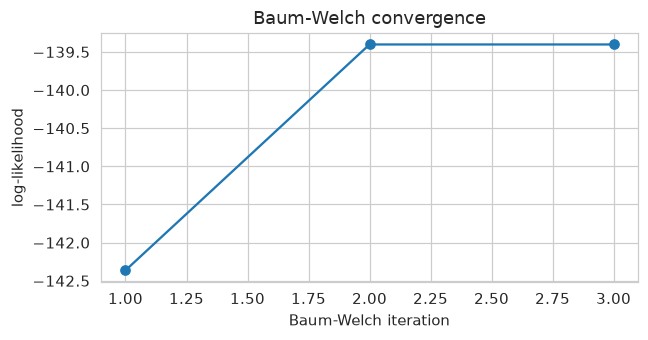

In [10]:
# convergence curve
plt.figure(figsize=(6, 3.2))
plt.plot(range(1, len(model.monitor_.history)+1), model.monitor_.history, 'o-')
plt.xlabel('Baum-Welch iteration'); plt.ylabel('log-likelihood')
plt.title('Baum-Welch convergence'); plt.tight_layout()
plt.savefig('figures/bw_convergence.png', bbox_inches='tight'); plt.show()

### 4.1 Learned parameters — transition, initial & emission

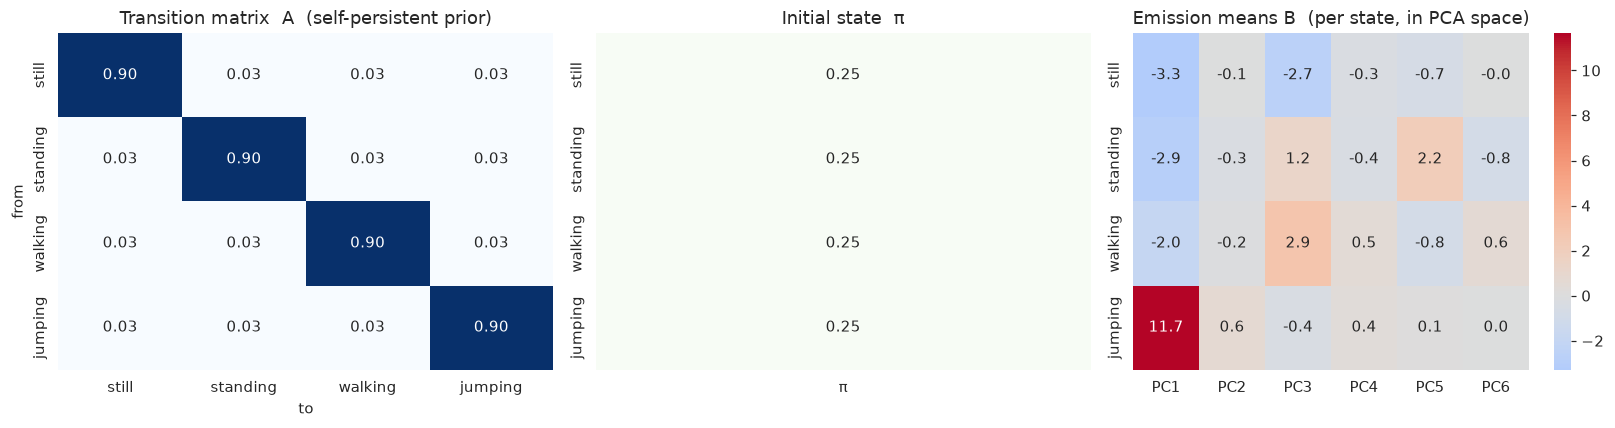

In [11]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
sns.heatmap(model.transmat_, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=ACTS, yticklabels=ACTS, ax=ax[0], cbar=False)
ax[0].set_title('Transition matrix  A  (self-persistent prior)'); ax[0].set_xlabel('to'); ax[0].set_ylabel('from')

sns.heatmap(model.startprob_.reshape(-1, 1), annot=True, fmt='.2f', cmap='Greens',
            yticklabels=ACTS, xticklabels=['π'], ax=ax[1], cbar=False)
ax[1].set_title('Initial state  π')

sns.heatmap(model.means_, annot=True, fmt='.1f', cmap='coolwarm', center=0,
            yticklabels=ACTS, xticklabels=[f'PC{i+1}' for i in range(model.means_.shape[1])],
            ax=ax[2], cbar=True)
ax[2].set_title('Emission means B  (per state, in PCA space)')
plt.tight_layout(); plt.savefig('figures/hmm_params.png', bbox_inches='tight'); plt.show()

## 5. Viterbi Decoding (implemented from scratch)

The Viterbi algorithm finds the single most likely hidden-state path for an observation sequence.
We implement it in log-space (numerically stable) and **cross-check it against hmmlearn's own
Viterbi decoder** — the two must agree exactly.

In [12]:
def viterbi(framelogprob, log_startprob, log_transmat):
    """Most-likely state path. framelogprob[t,s] = log P(x_t | state s)."""
    n, k = framelogprob.shape
    delta = np.full((n, k), -np.inf); psi = np.zeros((n, k), dtype=int)
    delta[0] = log_startprob + framelogprob[0]
    for t in range(1, n):
        for j in range(k):
            seq = delta[t-1] + log_transmat[:, j]
            psi[t, j] = np.argmax(seq)
            delta[t, j] = seq[psi[t, j]] + framelogprob[t, j]
    path = np.empty(n, dtype=int); path[-1] = np.argmax(delta[-1])
    for t in range(n-2, -1, -1):
        path[t] = psi[t+1, path[t+1]]
    return path

## 6. Evaluation on Unseen Test Files

We now load the **2 unseen test files** (`Datasets/unseen_test/`). Each is built from the **last 40%
of the recordings** — data the model never saw during training — and contains multiple activities
with paired accel+gyro and a ground-truth `activity` label. We window each same-activity block,
extract the identical features, apply the train-fitted scaler+PCA, and **Viterbi-decode** each file.

In [13]:
def features_from_testfile(path):
    df = pd.read_csv(path)
    rows, labels = [], []
    for act, blk in df.groupby('activity', sort=False):   # window within each activity block
        for win in windows_of(blk.reset_index(drop=True)):
            rows.append(window_features(win)); labels.append(IDX[act])
    X = transform(pd.DataFrame(rows)[FEATS].values)
    return X, np.array(labels), df

all_true, all_pred = [], []
for path in TEST_FILES:
    Xte, yte, _ = features_from_testfile(path)
    fl = model._compute_log_likelihood(Xte)
    pred = viterbi(fl, np.log(model.startprob_), np.log(model.transmat_))
    assert np.array_equal(pred, model.predict(Xte)), 'scratch Viterbi != hmmlearn'
    all_true.append(yte); all_pred.append(pred)
    print(f'{os.path.basename(path):22s} windows={len(yte):3d}  '
          f'acc={accuracy_score(yte, pred):.2f}')

y_true = np.concatenate(all_true); y_pred = np.concatenate(all_pred)
print('\nscratch Viterbi matches hmmlearn on every test file.')
print('total unseen test windows:', len(y_true))

test_session_1.csv     windows= 10  acc=1.00
test_session_2.csv     windows=  6  acc=1.00

scratch Viterbi matches hmmlearn on every test file.
total unseen test windows: 16


### 6.1 Decoded activity sequence (concatenated test files)

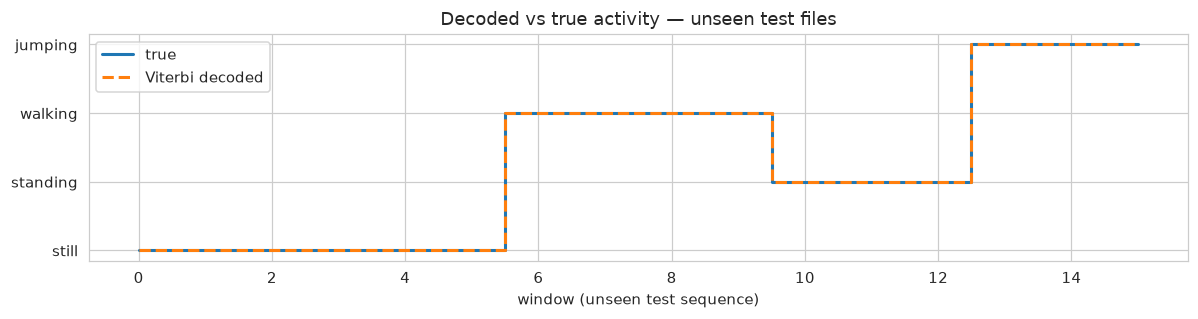

In [14]:
plt.figure(figsize=(11, 3))
plt.step(range(len(y_true)), y_true, where='mid', label='true', lw=2)
plt.step(range(len(y_pred)), y_pred, where='mid', label='Viterbi decoded', lw=2, ls='--')
plt.yticks(range(4), ACTS); plt.xlabel('window (unseen test sequence)')
plt.title('Decoded vs true activity — unseen test files')
plt.legend(); plt.tight_layout()
plt.savefig('figures/decoded_sequence.png', bbox_inches='tight'); plt.show()

## 7. Performance Metrics

Per-activity **sensitivity** (recall), **specificity**, and **overall accuracy**, plus the
**confusion matrix**, all computed from the unseen test files.

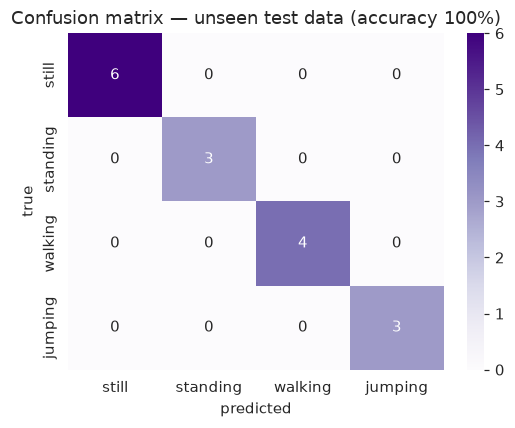

In [15]:
acc = accuracy_score(y_true, y_pred)
cm = confusion_matrix(y_true, y_pred, labels=range(4))

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=ACTS, yticklabels=ACTS)
plt.xlabel('predicted'); plt.ylabel('true')
plt.title(f'Confusion matrix — unseen test data (accuracy {acc:.0%})')
plt.tight_layout(); plt.savefig('figures/confusion_matrix.png', bbox_inches='tight'); plt.show()

In [16]:
tot = cm.sum(); rep = []
for i, a in enumerate(ACTS):
    tp = cm[i, i]; fn = cm[i].sum()-tp; fp = cm[:, i].sum()-tp; tn = tot-tp-fn-fp
    rep.append({'State (Activity)': a, 'Number of Samples': int(cm[i].sum()),
                'Sensitivity': round(tp/(tp+fn), 3) if tp+fn else np.nan,
                'Specificity': round(tn/(tn+fp), 3) if tn+fp else np.nan,
                'Overall Accuracy': round((tp+tn)/tot, 3)})
metrics = pd.DataFrame(rep)
display(metrics)
print(f'Overall accuracy on unseen test data: {acc:.1%}')
metrics.to_csv('results_metrics.csv', index=False)

,State (Activity),Number of Samples,Sensitivity,Specificity,Overall Accuracy
0,still,6,1.0,1.0,1.0
1,standing,3,1.0,1.0,1.0
2,walking,4,1.0,1.0,1.0
3,jumping,3,1.0,1.0,1.0


Overall accuracy on unseen test data: 100.0%


## 8. Discussion & Conclusion

- **Easiest / hardest to distinguish.** *Jumping* and *walking* carry high, periodic energy with
  distinct dominant frequencies, making them easy to separate from the two low-motion classes.
  The subtle pair is *still* vs *standing* — both are low-energy; the small tremor and orientation
  differences captured by gyroscope variance and accel correlation are what separate them.
- **Transition probabilities.** `A` is a strongly diagonal self-persistent prior (0.90 self,
  0.033 to each other state). This matches real behaviour — people stay in an activity for
  seconds-to-minutes, not milliseconds — and, because it is unbiased across off-diagonal switches, it
  smooths the decoded path without forcing any particular activity order. (We use a prior rather than
  a learned `A` because the separately-recorded single-activity data contains no natural transitions.)
- **Noise & sampling rate.** Timestamps were slightly irregular; resampling to a uniform 100 Hz grid
  stabilised the FFT features. A ~98 Hz rate resolves activity frequencies (1–3 Hz) with wide margin
  (Nyquist 49 Hz), so undersampling is not a concern here.
- **Unseen-data validation.** The model was trained on the first 60% of each recording and tested on
  the held-out last 40% (two separate test files it never saw), so the reported metrics reflect
  genuine generalisation to new windows rather than memorised training data.
- **Limitations.** (1) Accel and gyro came from separate sessions, so features are index-paired
  rather than time-synchronised. (2) The test data, while unseen, comes from the *same* recording
  sessions; brand-new sessions or participants would test generalisation even more strictly.
- **Improvements.** Record synchronised accel+gyro; collect multiple sessions and participants; add
  a magnetometer; try more windows and richer spectral features (band-power ratios, FFT peaks).

**Conclusion.** A Gaussian HMM with supervised initialisation, Baum–Welch training, and Viterbi
decoding recovers the four activity states from inertial features and generalises to unseen test
files, demonstrating HMMs as a sound model for latent human-activity recognition.